# Simulations of neutrino system (N=3)

In [2]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares  
from core_functions_Trotter import *

### Some $N=3$ analysis

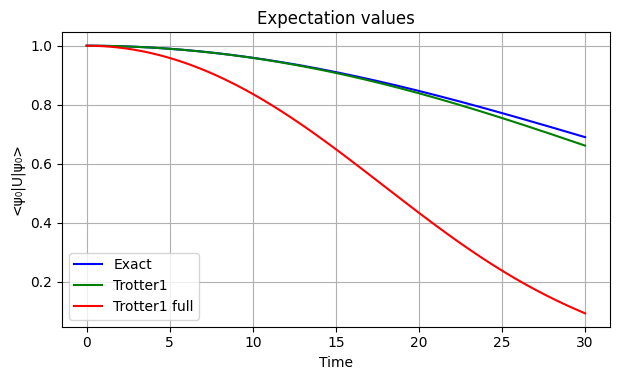

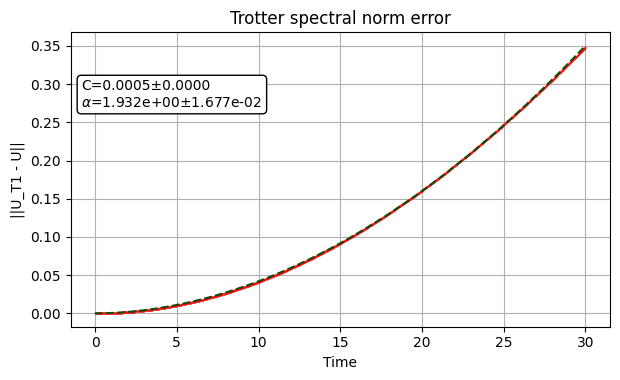

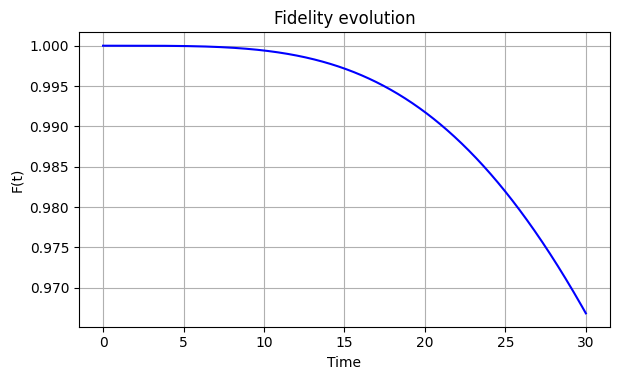

In [3]:
couplings, _ = fp_couplings(3, 0.99, 10)
tlist = np.linspace(0, 30, 1000)
I = qt.qeye(2)

def pauli_tensors(pauli):
    return [qt.tensor(*(pauli if i==j else I for j in range(3))) for i in range(3)]

sx, sy, sz = pauli_tensors(qt.sigmax()), pauli_tensors(qt.sigmay()), pauli_tensors(qt.sigmaz())
psi0 = qt.tensor(qt.basis(2,0), qt.basis(2,1), qt.basis(2,0))
c = couplings

E_tr1 = 0.25 * (
    (sx[0]*sz[1]*sy[2] + sz[0]*sx[1]*sy[2])*(c["g1_2"]*c["g1_3"] + c["g1_2"]*c["g2_3"] - 3*c["g1_3"]*c["g2_3"]) +
    (sx[0]*sy[1]*sz[2] + sz[0]*sy[1]*sz[2])*(c["g1_2"]*c["g1_3"] + c["g1_3"]*c["g2_3"] - 3*c["g1_2"]*c["g2_3"]) +
    (sy[0]*sx[1]*sz[2] + sy[0]*sz[1]*sx[2])*(c["g1_2"]*c["g2_3"] + c["g1_3"]*c["g2_3"] - 3*c["g1_2"]*c["g1_3"])
)

H = c["g1_2"]*(sx[0]*sx[1] + sy[0]*sy[1] + sz[0]*sz[1]) + \
    c["g1_3"]*(sx[0]*sx[2] + sy[0]*sy[2] + sz[0]*sz[2]) + \
    c["g2_3"]*(sx[1]*sx[2] + sy[1]*sy[2] + sz[1]*sz[2])

H_XY = c["g1_2"]*(sx[0]*sx[1] + sy[0]*sy[1]) + \
       c["g1_3"]*(sx[0]*sx[2] + sy[0]*sy[2]) + \
       c["g2_3"]*(sx[1]*sx[2] + sy[1]*sy[2])

H_XZ = c["g1_2"]*(sx[0]*sx[1] + sz[0]*sz[1]) + \
       c["g1_3"]*(sx[0]*sx[2] + sz[0]*sz[2]) + \
       c["g2_3"]*(sx[1]*sx[2] + sz[1]*sz[2])

H_YZ = c["g1_2"]*(sy[0]*sy[1] + sz[0]*sz[1]) + \
       c["g1_3"]*(sy[0]*sy[2] + sz[0]*sz[2]) + \
       c["g2_3"]*(sy[1]*sy[2] + sz[1]*sz[2])

# vectorized evolution of expectation values
def evolve_expect_vectorized(H, E_tr1, psi, times):
    U_heis = [(-1j*H*t).expm() for t in times]
    U_trot = [(-1j*(H + E_tr1*t)*t).expm() for t in times]
    U_T1 = [(-1j*(H_YZ)*t).expm()*(-1j*(H_XZ)*t).expm()*(-1j*(H_XY)*t).expm() for t in times]
    exp_heis = qt.expect(U_heis, psi)
    exp_trot = qt.expect(U_trot, psi)
    exp_T1 = qt.expect(U_T1, psi)
    return np.real(exp_heis), np.real(exp_trot), np.real(exp_T1), U_heis, U_trot, U_T1

U_heis_vals, U_trot_vals, U_T1_vals, U_heis_ops, U_trot_ops, U_T1_ops = evolve_expect_vectorized(H, E_tr1, psi0, tlist)

fig, ax = plt.subplots(figsize=(6.3,3.9))
ax.plot(tlist, U_heis_vals, 'b', label="Exact")
ax.plot(tlist, U_trot_vals, 'g', label="Trotter1")
ax.plot(tlist, U_T1_vals, 'r', label="Trotter1 full")
ax.set_title("Expectation values")
ax.set_xlabel("Time"); ax.set_ylabel(r"<ψ₀|U|ψ₀>"); ax.legend(); ax.grid(); plt.tight_layout(); plt.show()

# spectral norm difference
norm_diff = np.array([np.linalg.norm(Ut.full() - Uh.full(), 2) for Uh, Ut in zip(U_heis_ops, U_trot_ops)])
err = (norm_diff.max() - norm_diff.min()) * 0.05

def fit_model(t, C, alpha): 
    return C*t**alpha

m = Minuit(LeastSquares(tlist, norm_diff, err, fit_model), C=0.5, alpha=0.5)
m.limits["C"] = (0,None); m.migrad(); m.hesse()
C, alpha = m.values["C"], m.values["alpha"]

fig, ax = plt.subplots(figsize=(6.3,3.9))
ax.plot(tlist, norm_diff, 'ro', ms=0.4)
ax.plot(tlist, fit_model(tlist, C, alpha), '--', color="#0C4E0C")
ax.set_title("Trotter spectral norm error")
ax.set_xlabel("Time"); ax.set_ylabel(r"||U_T1 - U||")
ax.text(0.02, 0.84,
        rf"C={C:.4f}±{m.errors['C']:.4f}"+"\n"+rf"$\alpha$={alpha:.3e}±{m.errors['alpha']:.3e}",
        transform=ax.transAxes, fontsize=10, va="top", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.grid()
plt.tight_layout()
plt.show()

# vectorized fidelity
fidelity = np.array([abs((Ut*psi0).dag() * (Uh*psi0)) for Uh, Ut in zip(U_heis_ops, U_trot_ops)])
fig, ax = plt.subplots(figsize=(6.3,3.9))
ax.plot(tlist, fidelity, 'b')
ax.set_title("Fidelity evolution")
ax.set_xlabel("Time"); ax.set_ylabel(r"F(t)"); ax.grid(); plt.tight_layout(); plt.show()

### $\|U-U_{YZ}U_{XZ}U_{XY}\|(t)$

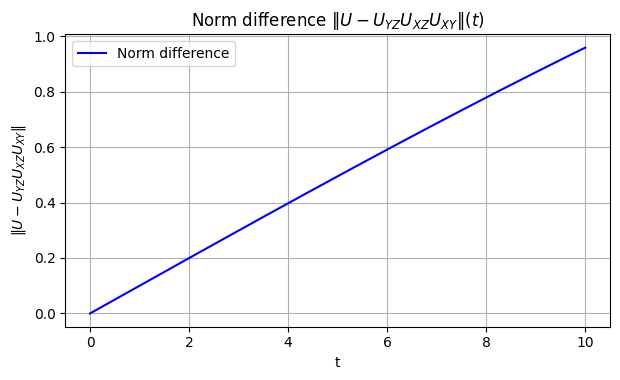

In [ ]:
couplings, _ = fp_couplings(3, 0.99, 10)
tlist = np.linspace(0, 10, 1000)
I = qt.qeye(2)

def pauli_tensors(pauli):
    return [qt.tensor(*(pauli if i==j else I for j in range(3))) for i in range(3)]

sx, sy, sz = pauli_tensors(qt.sigmax()), pauli_tensors(qt.sigmay()), pauli_tensors(qt.sigmaz())
psi0 = qt.tensor(qt.basis(2,0), qt.basis(2,1), qt.basis(2,0))
c = couplings

H = c["g1_2"]*(sx[0]*sx[1] + sy[0]*sy[1] + sz[0]*sz[1]) + \
    c["g1_3"]*(sx[0]*sx[2] + sy[0]*sy[2] + sz[0]*sz[2]) + \
    c["g2_3"]*(sx[1]*sx[2] + sy[1]*sy[2] + sz[1]*sz[2])

H_XY = c["g1_2"]*(sx[0]*sx[1] + sy[0]*sy[1]) + \
       c["g1_3"]*(sx[0]*sx[2] + sy[0]*sy[2]) + \
       c["g2_3"]*(sx[1]*sx[2] + sy[1]*sy[2])

H_XZ = c["g1_2"]*(sx[0]*sx[1] + sz[0]*sz[1]) + \
       c["g1_3"]*(sx[0]*sx[2] + sz[0]*sz[2]) + \
       c["g2_3"]*(sx[1]*sx[2] + sz[1]*sz[2])

H_YZ = c["g1_2"]*(sy[0]*sy[1] + sz[0]*sz[1]) + \
       c["g1_3"]*(sy[0]*sy[2] + sz[0]*sz[2]) + \
       c["g2_3"]*(sy[1]*sy[2] + sz[1]*sz[2])

# vectorized evolution of norm difference between exact and first order Trotter propagators
def evol_norm_difference(times):
    exact_U_vls = np.array([(-1j*H*t).expm() for t in times])
    Trotter1_U_vls = np.array([(-1j*(H_YZ)*t).expm()*(-1j*(H_XZ)*t).expm()*(-1j*(H_XY)*t).expm() for t in times])
    norm_diff = np.array([np.max(np.linalg.svd((exact_U_vls[i] - Trotter1_U_vls[i]).full(), compute_uv=False)) for i in range(0, len(times))])
    return exact_U_vls, Trotter1_U_vls, norm_diff

U_exact, U_Trotter1, U_norm_diff = evol_norm_difference(tlist)

fig, ax = plt.subplots(figsize=(6.3,3.9))
ax.plot(tlist, U_norm_diff, 'b', label="Norm difference")
ax.set_title(r"Norm difference $\|U-U_{YZ}U_{XZ}U_{XY}\|(t)$")
ax.set_xlabel("t"); ax.set_ylabel(r"$\|U-U_{YZ}U_{XZ}U_{XY}\|$"); ax.legend(); ax.grid(); plt.tight_layout(); plt.show()


### $\|(U-U_{YZ}U_{XZ}U_{XY})\vert\psi\rangle\|(t)$

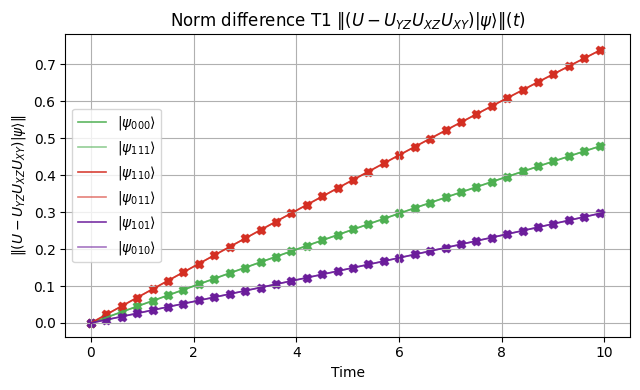

In [31]:
couplings, _ = fp_couplings(3, 0.99, 10)
tlist = np.linspace(0, 10, 1000)
I = qt.qeye(2)

def pauli_tensors(pauli):
    return [qt.tensor(*(pauli if i==j else I for j in range(3))) for i in range(3)]

sx, sy, sz = pauli_tensors(qt.sigmax()), pauli_tensors(qt.sigmay()), pauli_tensors(qt.sigmaz())

c = couplings

H = c["g1_2"]*(sx[0]*sx[1] + sy[0]*sy[1] + sz[0]*sz[1]) + \
    c["g1_3"]*(sx[0]*sx[2] + sy[0]*sy[2] + sz[0]*sz[2]) + \
    c["g2_3"]*(sx[1]*sx[2] + sy[1]*sy[2] + sz[1]*sz[2])

H_XY = c["g1_2"]*(sx[0]*sx[1] + sy[0]*sy[1]) + \
       c["g1_3"]*(sx[0]*sx[2] + sy[0]*sy[2]) + \
       c["g2_3"]*(sx[1]*sx[2] + sy[1]*sy[2])

H_XZ = c["g1_2"]*(sx[0]*sx[1] + sz[0]*sz[1]) + \
       c["g1_3"]*(sx[0]*sx[2] + sz[0]*sz[2]) + \
       c["g2_3"]*(sx[1]*sx[2] + sz[1]*sz[2])

H_YZ = c["g1_2"]*(sy[0]*sy[1] + sz[0]*sz[1]) + \
       c["g1_3"]*(sy[0]*sy[2] + sz[0]*sz[2]) + \
       c["g2_3"]*(sy[1]*sy[2] + sz[1]*sz[2])

psi000 = qt.tensor(qt.basis(2,0), qt.basis(2,0), qt.basis(2,0)) # |000>
psi110 = qt.tensor(qt.basis(2,1), qt.basis(2,1), qt.basis(2,0)) # |110>
psi011 = qt.tensor(qt.basis(2,0), qt.basis(2,1), qt.basis(2,1)) # |011>
psi101 = qt.tensor(qt.basis(2,1), qt.basis(2,0), qt.basis(2,1)) # |101>
psi010 = qt.tensor(qt.basis(2,0), qt.basis(2,1), qt.basis(2,0)) # |010>
psi111 = qt.tensor(qt.basis(2,1), qt.basis(2,1), qt.basis(2,1)) # |111>

exact_U_vls = np.array([(-1j*H*t).expm() for t in tlist])
Trotter1_U_vls = np.array([(-1j*(H_YZ)*t).expm()*(-1j*(H_XZ)*t).expm()*(-1j*(H_XY)*t).expm() for t in tlist])

def evol_norm_difference_psi(times, psi):
    norm_diff_psi = np.array([np.max(np.linalg.svd(((exact_U_vls[i] - Trotter1_U_vls[i])*psi).full(), compute_uv=False)) for i in range(0, len(times))])
    return exact_U_vls, Trotter1_U_vls, norm_diff_psi

_, _, U_norm_diff_psi000 = evol_norm_difference_psi(tlist, psi000)
_, _, U_norm_diff_psi110 = evol_norm_difference_psi(tlist, psi110)
_, _, U_norm_diff_psi011 = evol_norm_difference_psi(tlist, psi011)
_, _, U_norm_diff_psi101 = evol_norm_difference_psi(tlist, psi101)
_, _, U_norm_diff_psi010 = evol_norm_difference_psi(tlist, psi010)
_, _, U_norm_diff_psi111 = evol_norm_difference_psi(tlist, psi111)


#fig, ax = plt.subplots()
#ax.scatter(tlist, U_norm_diff_psi000, marker="X", s=20, color="#48F080", label=r"$\vert\psi_{000}\rangle$")
#ax.scatter(tlist, U_norm_diff_psi111, marker="o", s=5, color="#A81961", label=r"$\vert\psi_{111}\rangle$")
#ax.scatter(tlist, U_norm_diff_psi110, marker="X", s=20, color="#D42D21", label=r"$\vert\psi_{110}\rangle$")
#ax.scatter(tlist, U_norm_diff_psi011, marker="o", s=5, color="#1181A3", label=r"$\vert\psi_{011}\rangle$")
#ax.scatter(tlist, U_norm_diff_psi101, marker="X", s=20, color="#F32DD2", label=r"$\vert\psi_{101}\rangle$")
#ax.scatter(tlist, U_norm_diff_psi010, marker="o", s=5, color="#48F080", label=r"$\vert\psi_{010}\rangle$")

fig,ax=plt.subplots(figsize=(6.5,4))

state_pairs = [
    (r"$\vert\psi_{000}\rangle$", U_norm_diff_psi000, r"$\vert\psi_{111}\rangle$", U_norm_diff_psi111,"#4CAF50"),
    (r"$\vert\psi_{110}\rangle$", U_norm_diff_psi110, r"$\vert\psi_{011}\rangle$", U_norm_diff_psi011,"#D42D21"),
    (r"$\vert\psi_{101}\rangle$", U_norm_diff_psi101, r"$\vert\psi_{010}\rangle$", U_norm_diff_psi010,"#6A1B9A")
]

marker_step=30

for label_1, data_1, label_2, data_2, color in state_pairs:
    ax.plot(tlist, data_1, color=color, linewidth=1.2, alpha=0.9, label=label_1)
    ax.plot(tlist, data_2, color=color, linewidth=1.2, alpha=0.6, label=label_2)
    ax.scatter(tlist[::marker_step], data_1[::marker_step], marker="X", s=35, color=color, alpha=0.9)
    ax.scatter(tlist[::marker_step], data_2[::marker_step], marker="o", s=20, color=color, alpha=0.7)

ax.set_title(r"Norm difference T1 $\left\|\left(U-U_{YZ}U_{XZ}U_{XY}\right)\vert\psi\rangle\right\|(t)$")
ax.set_xlabel("Time")
ax.set_ylabel(r"$\left\|\left(U-U_{YZ}U_{XZ}U_{XY}\right)\vert\psi\rangle\right\|$")

ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="top", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

ax.legend()
plt.grid()
plt.tight_layout()
plt.show()


We observe that $\vert110\rangle$ and $\vert011\rangle$ have the same norm evolution and $\vert101\rangle$ and $\vert010\rangle$ also. 

-0.9999991111112648


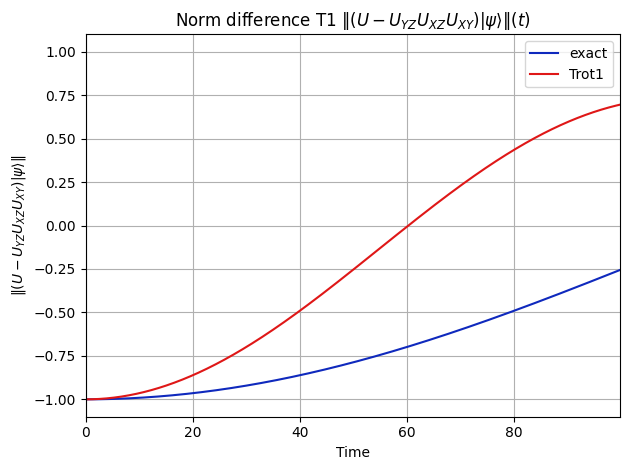

In [39]:
couplings, _ = fp_couplings(3, 0.99, 1)
tlist = np.linspace(0, 10, 1000)
I = qt.qeye(2)

def pauli_tensors(pauli, N):
    return [qt.tensor(*(pauli if i==j else I for j in range(N))) for i in range(N)]

sx, sy, sz = pauli_tensors(qt.sigmax(), N=3), pauli_tensors(qt.sigmay(), N=3), pauli_tensors(qt.sigmaz(), N=3)

c = couplings

H = c["g1_2"]*(sx[0]*sx[1] + sy[0]*sy[1] + sz[0]*sz[1]) + \
    c["g1_3"]*(sx[0]*sx[2] + sy[0]*sy[2] + sz[0]*sz[2]) + \
    c["g2_3"]*(sx[1]*sx[2] + sy[1]*sy[2] + sz[1]*sz[2])

H_XY = c["g1_2"]*(sx[0]*sx[1] + sy[0]*sy[1]) + \
       c["g1_3"]*(sx[0]*sx[2] + sy[0]*sy[2]) + \
       c["g2_3"]*(sx[1]*sx[2] + sy[1]*sy[2])

H_XZ = c["g1_2"]*(sx[0]*sx[1] + sz[0]*sz[1]) + \
       c["g1_3"]*(sx[0]*sx[2] + sz[0]*sz[2]) + \
       c["g2_3"]*(sx[1]*sx[2] + sz[1]*sz[2])

H_YZ = c["g1_2"]*(sy[0]*sy[1] + sz[0]*sz[1]) + \
       c["g1_3"]*(sy[0]*sy[2] + sz[0]*sz[2]) + \
       c["g2_3"]*(sy[1]*sy[2] + sz[1]*sz[2])


dt = 0.1
N_iter = 1000

U_exact_dt = (-1j*H*dt).expm()
U_Trot1_dt = (-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*dt).expm()*(-1j*(H_XY)*dt).expm()

print(qt.expect(sz[0], U_exact_dt*psi110))

psi_exact = []
psi_Trot1 = []

psi110 = qt.tensor(qt.basis(2,1), qt.basis(2,1), qt.basis(2,0)) # |110>

psi_exact.append(psi110)
psi_Trot1.append(psi110)

for i in range(1, N_iter):
    psi_exact.append(U_exact_dt*psi_exact[i-1])
    psi_Trot1.append(U_Trot1_dt*psi_Trot1[i-1])

tlist = [dt*k for k in range(0, N_iter)]
exact_Z1_expvl = [qt.expect(sz[0], state) for state in psi_exact]
Trot1_Z1_expvl = [qt.expect(sz[0], state) for state in psi_Trot1]

fig, ax=plt.subplots()

ax.plot(tlist, exact_Z1_expvl, color="#0F29BD", label="exact")
ax.plot(tlist, Trot1_Z1_expvl, color="#DF1717", label="Trot1")

ax.set_title(r"Norm difference T1 $\left\|\left(U-U_{YZ}U_{XZ}U_{XY}\right)\vert\psi\rangle\right\|(t)$")
ax.set_xlabel("Time")
ax.set_ylabel(r"$\left\|\left(U-U_{YZ}U_{XZ}U_{XY}\right)\vert\psi\rangle\right\|$")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(tlist), np.max(tlist))
ax.set_ylim(-1.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()
